In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make NumPy printouts easier to read.
#np.set_printoptions(precision=3, suppress=True)

import tensorflow as tf

from tensorflow import keras
from keras import layers

print(tf.__version__)
!python --version

import os

2.19.0
Python 3.12.12


## Dataset


In [ ]:
dataset = pd.DataFrame(np.array([
#['TiN', 'RF', 'Power_W', 'Distance_mm', 'P_work_mT', 'Ar_sccm', 'N2_sccm', 'Ar_per', 'N2_per', 'Temp_C', 'Bias_kV', 'TargetDiameter_in', 'Rate_A4min'] # ['Ref', 'Substrate', 'Grain_len_nm', 'Grain_len_nm', 'Ox_per', 'Ti2N_Ratio', 'Res_uOhmcm', 'Time_min', 'Thk_nm', 'P_base_uT']
[1, 1, 250, np.nan, 5.6, np.nan, 0, 100, 0, 25, 0, 2, 42], # [1, Si-100, 39, 39, np.nan, 1.1, np.nan, np.nan, np.nan, 4.8],
[1, 1, 250, np.nan, 5.6, np.nan, 0, 100, 0, 25, 0.1, 2, 18], # [1, Si-100, 10, 10, np.nan, 1.1, np.nan, np.nan, np.nan, 4.8],
[1, 1, 16.6, np.nan, 0.25, np.nan, 0, 100, 0, 350, 0, np.nan, 15], # [12, Si, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 0],
[1, 1, 20, np.nan, 0.3, np.nan, 0, 100, 0, 350, 0, np.nan, 27], # [12, Si, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 0],
[1, 1, 40, np.nan, 0.41, np.nan, 0, 100, 0, 350, 0, np.nan, 29], # [12, Si, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 0],
[1, 1, 60, np.nan, 0.52, np.nan, 0, 100, 0, 350, 0, np.nan, 37], # [12, Si, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 0],
[1, 1, 65.5, np.nan, 0.57, np.nan, 0, 100, 0, 350, 0, np.nan, 45], # [12, Si, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 0],
[1, 1, 300, 70, 2, 10, 0, 100, 0, 25, 0, 8, 40], # [14, Si-100, 0, 0, np.nan, np.nan, 216, np.nan, np.nan, 4],
[1, 1, 300, 70, 5, 65, 0, 100, 0, 25, 0, np.nan, 50], # [14, Si-101, 13, 13, np.nan, np.nan, np.nan, np.nan, np.nan, 4],
[1, 1, 300, 70, 9, 80, 0, 100, 0, 25, 0, np.nan, 54.6], # [14, Si-102, 20, 20, np.nan, np.nan, 0.235, np.nan, np.nan, 4],
[1, 1, 300, 70, 10, 95, 0, 100, 0, 25, 0, np.nan, 60], # [14, Si-103, 95, 95, np.nan, np.nan, np.nan, np.nan, np.nan, 4],
[1, 1, 200, 70, 9, 80, 0, 100, 0, 25, 0, np.nan, 8.4], # [14, Si-104, 10, 10, np.nan, np.nan, np.nan, np.nan, np.nan, 4],
[1, 1, 300, 70, 9, 80, 0, 100, 0, 25, 0, np.nan, 54.6], # [14, Si-105, 47, 47, np.nan, np.nan, np.nan, 60, 300, 4],
[1, 1, 100, np.nan, 15, 30, 0, 100, 0, 25, 0, np.nan, 100], # [17, Ge-n-100, np.nan, np.nan, np.nan, 1, 140, np.nan, 50, 0],
[1, 1, 250, np.nan, 3, np.nan, 0, 100, 0, 200, 0, 4, 14], # [18, Si, 50, 50, np.nan, np.nan, np.nan, np.nan, np.nan, 0.1],
[1, 1, 200, 20, 14, np.nan, 0, 100, 0, 25, 0.2, 3, 58], # [20, ss, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 0.1],
[1, 1, 200, 40, 14, np.nan, 0, 100, 0, 25, 0.2, 3, 55], # [20, ss, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 0.1],
[1, 1, 200, 60, 14, np.nan, 0, 100, 0, 25, 0.2, 3, 48], # [20, ss, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 0.1],
[1, 1, 200, 80, 14, np.nan, 0, 100, 0, 25, 0.2, 3, 30], # [20, ss, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 0.1],
[1, 1, 200, 10, 14, np.nan, 0, 100, 0, 25, 0.2, 3, 20], # [20, ss, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 0.1],
[1, 1, 200, 12, 14, np.nan, 0, 100, 0, 25, 0.2, 3, 20], # [20, ss, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 0.1],
[1, 0, 600, 75, 7.5, np.nan, 0, 100, 0, 400, 0.05, np.nan, 393], # [23, Zr, np.nan, np.nan, np.nan, np.nan, np.nan, 600, 11790, 0],
[1, 0, 600, 75, 7.5, np.nan, 0, 100, 0, 400, 0.1, np.nan, 383.3], # [23, Zr, np.nan, np.nan, np.nan, np.nan, np.nan, 600, 11500, 0],
[1, 0, 600, 75, 7.5, np.nan, 0, 100, 0, 400, 0.2, np.nan, 200], # [23, Zr, np.nan, np.nan, np.nan, np.nan, np.nan, 600, 6000, 0],
[1, 0, 600, 75, 7.5, np.nan, 0, 100, 0, 400, 0.3, np.nan, 223], # [23, Zr, np.nan, np.nan, np.nan, np.nan, np.nan, 600, 6700, 0],
[1, 1, 500, 70, 3.37, 30, 0, 100, 0, 25, 0, 2.36, 170], # [24, Si, np.nan, np.nan, np.nan, np.nan, np.nan, 4, 68, 4],
[1, 0, 25, 100, 5, 30, 0, 100, 0, 25, 0, 2, 15], # [25, SiO2-100, np.nan, np.nan, np.nan, np.nan, np.nan, 10, 15, 6],
[1, 0, 50, 100, 5, 30, 0, 100, 0, 25, 0, 2, 33], # [25, SiO2-100, np.nan, np.nan, np.nan, np.nan, 175, 10, 33, 6],
[1, 0, 75, 100, 5, 30, 0, 100, 0, 25, 0, 2, 60], # [25, SiO2-100, np.nan, np.nan, np.nan, np.nan, 100, 10, 60, 6],
[1, 0, 100, 100, 5, 30, 0, 100, 0, 25, 0, 2, 68], # [25, SiO2-100, np.nan, np.nan, np.nan, np.nan, 20, 10, 68, 6],
[1, 0, 150, 100, 5, 30, 0, 100, 0, 25, 0, 2, 100], # [25, SiO2-100, np.nan, np.nan, np.nan, np.nan, 8, 10, 100, 6],
#[1, 0, 6500, 70, 3, 55, 55, 50, 50, 25, 0, np.nan, 311], # [26, Si, np.nan, np.nan, np.nan, np.nan, np.nan, 10, 311, 3],
#[1, 0, 6500, 71, 3, 55, 55, 50, 50, 100, 0, np.nan, 222], # [26, Si, np.nan, np.nan, np.nan, np.nan, np.nan, 11, 222, 3],
#[1, 0, 6500, 72, 3, 55, 55, 50, 50, 200, 0, np.nan, 228], # [26, Si, np.nan, np.nan, np.nan, np.nan, np.nan, 12, 228, 3],
#[1, 0, 6500, 73, 3, 55, 55, 50, 50, 300, 0, np.nan, 282], # [26, Si, np.nan, np.nan, np.nan, np.nan, np.nan, 13, 282, 3],
[1, 1, 50, 100, 5, np.nan, 0, 80, 20, 25, 0, 1, 7], # [27, Si-001, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 100, 0],
[1, 1, 60, 100, 5, np.nan, 0, 80, 20, 25, 0, 1, 12], # [27, Si-001, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 150, 0],
[1, 0, 105, 70, 0.75, 100, 0, 100, 0, 25, 0, 4, 188.6], # [30, Si, np.nan, np.nan, np.nan, np.nan, 170, 5.83, 110, 0],
[1, 0, 62.5, 70, 45, 45, 0, 100, 0, 25, 0, 4, 300], # [30, Si, np.nan, np.nan, np.nan, np.nan, 1100, 5.83, 175, 0],
[1, 0, 105, 70, 0.75, 100, 0, 100, 0, 25, 0, 4, 361.4], # [30, Si, np.nan, np.nan, np.nan, np.nan, 170, 1.66, 60, 0],
[1, 0, 62.5, 70, 45, 45, 0, 100, 0, 25, 0, 4, 180.7], # [30, Si, np.nan, np.nan, np.nan, np.nan, 1100, 1.66, 30, 0],
[1, 0, 105, 70, 0.75, 100, 0, 100, 0, 25, 0, 4, 373.3], # [30, Si, np.nan, np.nan, np.nan, np.nan, 170, 3.75, 140, 0],
[1, 0, 62.5, 70, 45, 45, 0, 100, 0, 25, 0, 4, 133.3], # [30, Si, np.nan, np.nan, np.nan, np.nan, 1100, 3.75, 50, 0],
[1, 1, 300, 50, 70, 20, 0, 100, 0, np.nan, 0, 1, 13.3], # [32, SiO2-100, np.nan, np.nan, np.nan, np.nan, np.nan, 15, 20, 75],
[1, 0, 75, np.nan, 4, np.nan, 0, 100, 0, 100, 0, 1.96, 250], # [33, Si-100, np.nan, np.nan, np.nan, 2, np.nan, 5, 125, 2],
[1, 1, 300, 100, 5, np.nan, 0, 77, 23, 100, 0, 1, 6], # [37, Si-001, np.nan, np.nan, np.nan, np.nan, np.nan, 48, 30, 2],
[1, 1, np.nan, 40, 30, np.nan, 0, 100, 0, 500, 0, 2, 41.66], # [41, Si-100, np.nan, np.nan, np.nan, 2, np.nan, 240, 1000, 7],
[1, 1, 300, np.nan, np.nan, 80, 0, 100, 0, 25, 0, 8, 50], # [46, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 60, 300, 0],
[1, 1, 100, np.nan, 15, 40, 0, 100, 0, 25, 0, 4, 33.3], # [47, Si-p-100, np.nan, np.nan, np.nan, np.nan, np.nan, 45, 150, 10],
[1, 0, 700, 50, 1.5, np.nan, 0, 100, 0, 25, 0, 5.9, 9.3], # [48, SiO2, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 1000, 1],
[1, 0, 200, np.nan, 10.5, 10, 5, 67, 33, 25, 0, 3, 52.8], # [58, Si-100, np.nan, np.nan, np.nan, np.nan, 55.1, 5, np.nan, 1.5],
[1, 0, 250, np.nan, 10.5, 10, 5, 67, 33, 25, 0, np.nan, 58.5], # [58, Si-100, np.nan, np.nan, np.nan, np.nan, np.nan, 10, np.nan, 0],
[1, 0, 300, np.nan, 10.5, 10, 5, 67, 33, 25, 0, np.nan, 33.3], # [58, Si-100, np.nan, np.nan, np.nan, np.nan, np.nan, 15, np.nan, 0],
[1, 1, 100, np.nan, 15, 30, 0, 100, 0, 25, 0, np.nan, 100], # [60, Ge-n-100, np.nan, np.nan, np.nan, 1, np.nan, np.nan, 50, 0],
[1, 1, 60, np.nan, 6, 10, 0, 100, 0, 25, 0, np.nan, 7.8], # [63, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 19.5, 1],
[1, 0, 200, 134, 3, 12, 0, 100, 0, 25, 0, 2, 38], # [MICRO-Ti-1, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 2.5, 38, 5.2],
[1, 0, 200, 134, 3, 12, 0, 100, 0, 25, 0, 2, 52.2], # [MICRO-Ti-2, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 5, 52.2, 5.2],
[1, 0, 200, 134, 3, 12, 0, 100, 0, 25, 0, 2, 80.4], # [MICRO-Ti-3, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 10, 80.4, 5.2],
[1, 0, 200, 134, 3, 12, 0, 100, 0, 25, 0, 2, 121.6], # [MICRO-Ti-4, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 15, 121.6, 5.2],
[1, 0, 200, 134, 3, 12, 0, 100, 0, 25, 0, 2, 153.3], # [MICRO-Ti-5, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 20, 153.3, 5.2],
[1, 0, 200, 134, 3, 12, 0, 100, 0, 25, 0, 2, 387.6], # [MICRO-Cu-1, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 2.5, 96.9, 5.2],
[1, 0, 200, 134, 3, 12, 0, 100, 0, 25, 0, 2, 379.2], # [MICRO-Cu-2, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 5, 188.3, 5.2],
[1, 0, 200, 134, 3, 12, 0, 100, 0, 25, 0, 2, 363], # [MICRO-Cu-3, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 10, 363.3, 5.2],
[1, 0, 200, 134, 3, 12, 0, 100, 0, 25, 0, 2, 365], # [MICRO-Cu-4, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 15, 548.3, 5.2],
[1, 0, 200, 134, 3, 12, 0, 100, 0, 25, 0, 2, 363], # [MICRO-Cu-5, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 20, 726.6, 5.2],
[1, 0, 200, 134, 3, 12, 0, 100, 0, 25, 0, 2, 150.6], # [MICRO-Ag-1, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 2.5, 376.5, 5.2],
[1, 0, 200, 134, 3, 12, 0, 100, 0, 25, 0, 2, 159], # [MICRO-Ag-2, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 5, 796.3, 5.2],
[1, 0, 200, 134, 3, 12, 0, 100, 0, 25, 0, 2, 144], # [MICRO-Ag-3, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 15, 2166.7, 5.2],
[1, 0, 200, 134, 3, 12, 0, 100, 0, 25, 0, 2, 141], # [MICRO-Ag-4, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 20, 2816.7, 5.2],
[1, 0, 200, 134, 3, 12, 0, 100, 0, 25, 0, 2, 110.4], # [MICRO-Al-1, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 2.5, 276.6, 5.2],
[1, 0, 200, 134, 3, 12, 0, 100, 0, 25, 0, 2, 105.6], # [MICRO-Al-2, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 5, 529.5, 5.2],
[1, 0, 200, 134, 3, 12, 0, 100, 0, 25, 0, 2, 96], # [MICRO-Al-3, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 10, 959.4, 5.2],
[1, 0, 200, 134, 3, 12, 0, 100, 0, 25, 0, 2, 95.4], # [MICRO-Al-4, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 15, 1433.3, 5.2],
[1, 0, 200, 134, 3, 12, 0, 100, 0, 25, 0, 2, 96.6], # [MICRO-Al-5, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 20, 1933.3, 5.2],
[1, 1, 125, 134, 6, 9, 0, 100, 0, 25, 0, 2, 25], # [MICRO-NiO, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 18, 45, 5.2],
[1, 1, 75, 134, 3, 9, 0, 100, 0, 25, 0, 2, 10], # [MICRO-NiO-1, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 20, 20, 5.2],
[1, 1, 75, 134, 3, 9, 0, 100, 0, 100, 0, 2, 8.5], # [MICRO-NiO-2, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 23.5, 20, 5.2],
[1, 1, 75, 134, 3, 9, 0, 100, 0, 25, 0, 2, 16.5], # [MICRO-NiO-3, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 20, 33, 5.2],
[1, 1, 80, 134, 4, 9, 0, 100, 0, 25, 0, 2, 5], # [MICRO-ZnO-1, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 20, 10, 5.2],
[1, 1, 40, 134, 3, 9, 0, 100, 0, 270, 0, 2, 50], # [MICRO-ITO-1, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 20, 100, 5.2],
[1, 1, 40, 134, 3, 9, 0, 100, 0, 270, 0, 2, 33.3], # [MICRO-ITO-2, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 30, 100, 5.2],
[1, 1, 40, 134, 3, 9, 0, 100, 0, 170, 0, 2, 25], # [MICRO-ITO-3, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 40, 100, 5.2],
[1, 1, 40, 134, 3, 9, 0, 100, 0, 170, 0, 2, 32.5], # [MICRO-ITO-4, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 20, 65, 5.2],
[1, 1, 90, 134, 5, 10, 0, 100, 0, 350, 0, 2, 6.6], # [MICRO-SiO2-1, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 30, 20, 5.2],
[1, 1, 75, 134, 3, 12, 0, 100, 0, 350, 0, 2, 8], # [MICRO-Si3N4-1, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 20, 16, 5.2],
[1, 1, 75, 134, 3, 12, 0, 100, 0, 350, 0, 2, 6], # [MICRO-Si3N4-2, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 30, 18.1, 5.2],
[1, 1, 75, 134, 3, 12, 0, 100, 0, 350, 0, 2, 5.5], # [MICRO-Si3N4-3, Glass, np.nan, np.nan, np.nan, np.nan, np.nan, 40, 21.9, 5.2]
]), columns=[['TiN', 'RF', 'Power_W', 'Distance_mm', 'P_work_mT', 'Ar_sccm',	'N2_sccm', 'Ar_per', 'N2_per', 'Temp_C', 'Bias_kV', 'TargetDiameter_in', 'Rate_A4min']])


### Split datasset & features from labels

In [ ]:
train_dataset = dataset

train_features = train_dataset.copy()
train_labels = train_features.pop('Rate_A4min')

print(dataset.shape)
print(train_features.shape)
print(train_labels.shape)

(83, 13)
(83, 12)
(83, 1)


## Normalization

In [ ]:
def mean_nan(x):
  total = 0
  total_i = 0
  for i in x:
    if not np.isnan(i):
      total = total + i
      total_i = total_i + 1
  return total / total_i

def std_nan(x):
  total = 0
  total_i = 0
  mean = mean_nan(x)
  for i in x:
    if not np.isnan(i):
      total = total + (i - mean)**2
      total_i = total_i + 1
  total = total / total_i
  return total**0.5

def norm_nan(data):

  means = []
  stds = []

  for i in data.keys():
    x = np.array(data.loc[:,i], dtype=float)

    mean_x = mean_nan(x)
    std_x = std_nan(x)

    means.append(mean_x)
    stds.append(std_x)

    for j in range(len(x)):
      if not np.isnan(x[j]):
        if std_x == 0:
          x[j] = 0
        else:
          x[j] = (x[j] - mean_x) / std_x

    data.loc[:,i] = x

  return data, means, stds

train_features, means, stds = norm_nan(train_features)
train_features = train_features.fillna(0)

print(train_features)

train_features.describe().transpose()

print(means, stds)

    TiN        RF   Power_W Distance_mm P_work_mT   Ar_sccm   N2_sccm  \
0   0.0  0.941469  0.445060    0.000000 -0.202421  0.000000 -0.193649   
1   0.0  0.941469  0.445060    0.000000 -0.202421  0.000000 -0.193649   
2   0.0  0.941469 -1.178823    0.000000 -0.680701  0.000000 -0.193649   
3   0.0  0.941469 -1.155168    0.000000 -0.676231  0.000000 -0.193649   
4   0.0  0.941469 -1.016018    0.000000 -0.666397  0.000000 -0.193649   
..  ...       ...       ...         ...       ...       ...       ...   
78  0.0  0.941469 -1.016018    0.908395 -0.434856 -0.674812 -0.193649   
79  0.0  0.941469 -0.668142    0.908395 -0.256060 -0.638252 -0.193649   
80  0.0  0.941469 -0.772505    0.908395 -0.434856 -0.565131 -0.193649   
81  0.0  0.941469 -0.772505    0.908395 -0.434856 -0.565131 -0.193649   
82  0.0  0.941469 -0.772505    0.908395 -0.434856 -0.565131 -0.193649   

      Ar_per    N2_per    Temp_C   Bias_kV TargetDiameter_in  
0   0.271809 -0.271809 -0.548665 -0.363519         -0.417944


## Regression DNN

In [ ]:
dnn_model = keras.Sequential([
    layers.Input(shape=[len(train_features.keys())]),
    layers.Masking(mask_value=0),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

dnn_model.compile(loss='mean_absolute_error', optimizer=tf.keras.optimizers.Adam(0.01))

#dnn_model.compile(loss='mse', optimizer=tf.keras.optimizers.RMSprop(0.001), metrics=['mae', 'mse'])

#dnn_model.predict(train_features[:11]) # just to build the model

dnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,057 (19.75 KB)

 Trainable params: 5,057 (19.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=100)

history = dnn_model.fit(
    train_features, train_labels,
    validation_split=0.1, verbose=1, epochs=1000, callbacks=[early_stop])

history = dnn_model.fit(train_features, train_labels, validation_split=0.1, verbose=1, epochs=300, shuffle=True)

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 113.5588 - val_loss: 18.0990
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 110.7433 - val_loss: 15.9564
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 102.7677 - val_loss: 13.7658
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 105.5098 - val_loss: 14.3183
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 98.2196 - val_loss: 15.5512
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 92.2583 - val_loss: 17.1567
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 84.5999 - val_loss: 19.9751
Epoch 8/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 81.1840 - val_loss: 24.9412
Epoch 9/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 71.0708 - val_loss: 28.4016
Epoch 10/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 67.7988 - val_loss: 30.1812
Epoch 11/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 60.0646 - val_loss: 29.9242
Epoch 12/1000
3/3 ━━━━━━━━━━━━━━━━━━━

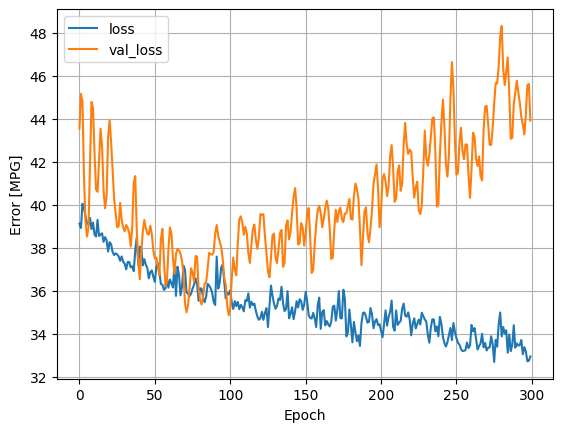

In [ ]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  #plt.ylim([0, 10])
  plt.xlabel('Epoch')
  plt.ylabel('Error [MPG]')
  plt.legend()
  plt.grid(True)

plot_loss(history)

### Performance

In [ ]:
test_results = {}

test_results['dnn_model'] = dnn_model.evaluate(train_features, train_labels, verbose=0)

pd.DataFrame(test_results, index=['Mean absolute error [Rate]']).T

,Mean absolute error [Rate]
dnn_model,34.128967


## Predictions


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


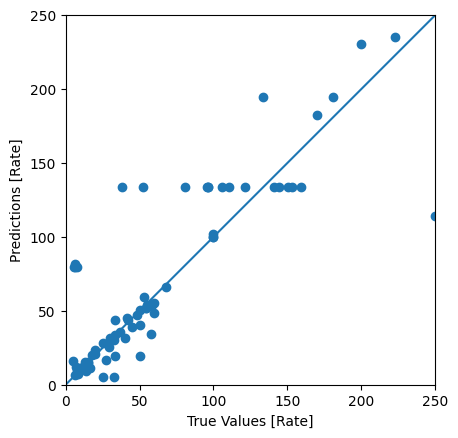

In [ ]:
train_predictions = dnn_model.predict(train_features).flatten()

plt.axes(aspect='equal')
plt.scatter(train_labels, train_predictions)
plt.xlabel('True Values [Rate]')
plt.ylabel('Predictions [Rate]')
lims = [0, 250]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims) # "_ = " avoids verbose plt

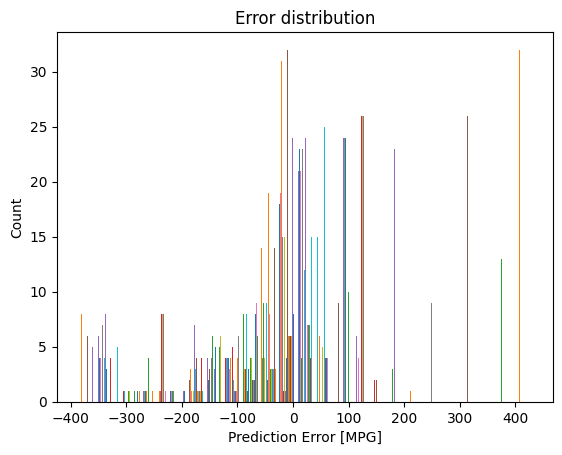

In [ ]:
error = train_predictions - train_labels['Rate_A4min'].values
plt.hist(error, bins=25)
plt.title("Error distribution")
plt.xlabel('Prediction Error [MPG]')
_ = plt.ylabel('Count')

##Save

In [ ]:
dnn_model.save('dnn_model_Rate.keras')

##Reload

In [ ]:
reloaded_model = tf.keras.models.load_model('dnn_model_Rate.keras')

def norm_input(_x) :
  x = np.array(_x, copy=True)
  for i in range(len(_x)):
    if not np.isnan(_x[i]):
      if stds[i] == 0:
        x[i] = 0
      else:
        x[i] = (_x[i] - means[i]) / stds[i]
    else:
      x[i] = 0
  return x.reshape(1, -1)

def myFunc(_x) :
  x = norm_input(_x)
  y = reloaded_model.predict(x)
  return y

def myFuncMin(_x) :
  x = norm_input(_x)
  y = 1000-reloaded_model.predict(x)
  return y

In [ ]:
# Test a depo
x = np.array([1,1,60,134,3,15,0,100,0,25,0,2], dtype=float) # y = 6.28
y = myFunc(x)
print(y)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
[[11.140395]]


In [ ]:
#os._exit(0)

This notebook introduced a few techniques to handle a regression problem. Here are a few more tips that may help:

- Mean squared error (MSE) (`tf.keras.losses.MeanSquaredError`) and mean absolute error (MAE) (`tf.keras.losses.MeanAbsoluteError`) are common loss functions used for regression problems. MAE is less sensitive to outliers. Different loss functions are used for classification problems.
- Similarly, evaluation metrics used for regression differ from classification.
- When numeric input data features have values with different ranges, each feature should be scaled independently to the same range.
- Overfitting is a common problem for DNN models, though it wasn't a problem for this tutorial. Visit the [Overfit and underfit](overfit_and_underfit.ipynb) tutorial for more help with this.

## Multi-objective optimization

NSGA-II: Non-dominated Sorting Genetic Algorithm, GA, DE - Differential Evolution

In [ ]:
from matplotlib import cm
import matplotlib.pyplot as plt
import numpy as np

!pip install -U pymoo

In [ ]:
# AJA Sputtercoater Orion 5 system : ACT 1500-F
# ['TiN', 'RF', 'Power_W', 'Distance_mm', 'P_work_mT', 'Ar_sccm', 'N2_sccm', 'Ar_per', 'N2_per', 'Temp_C', 'Bias_kV', 'TargetDiameter_in', 'Rate_A4min']

# Space for optimitation
#x00_range = [1,1]       # TiN
#x01_range = [1,1]       # RF
x02_range = [30,60]       # Power_W
x03_range = [44.5,146]   # Distance_mm
x04_range = [3,15]       # P_work_mT
x05_range = [5,20]       # Ar_sccm
#x06_range = [0,20]      # N2_sccm
#x07_range = [0,100]     # Ar_per
#x08_range = [0,100]     # N2_per
x09_range = [25,450]     # Temp_C
#x10_range = [0,0.4]     # Bias_kV
#x11_range = [2,2]       # TargetDiameter_in


In [ ]:
from pymoo.optimize import minimize
from pymoo.core.problem import Problem

#https://pymoo.org/algorithms/list.html

from pymoo.algorithms.moo.nsga2 import NSGA2
#from pymoo.algorithms.soo.nonconvex.de import DE

class ProblemWrapper(Problem):

  def _evaluate(self, designs, out, *args, **kwargs):
    res = []
    for design in designs:
      res.append(myFuncMin(design))
    out["F"] = np.array(res)

problem = ProblemWrapper(n_var=12, n_obj=1,
  xl=[1, 1, x02_range[0], x03_range[0], x04_range[0], x05_range[0], 0, 100, 0, x09_range[0], 0, 2],
  xu=[1, 1, x02_range[1], x03_range[1], x04_range[1], x05_range[1], 0, 100, 0, x09_range[1], 0, 2])

results = minimize(
    problem=problem,
    algorithm = NSGA2(pop_size=35),
    termination = ('n_gen', 15),
    verbose = True
)

print('Done')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━

In [ ]:
#columns = ['TiN', 'RF', 'Power_W', 'Distance_mm', 'P_work_mT', 'Ar_sccm', 'N2_sccm', 'Ar_per', 'N2_per', 'Temp_C', 'Bias_kV', 'TargetDiameter_in', 'Rate_A4min']

x = np.array(results.X, dtype=float)
y = myFunc(x)
print(x,y)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
[  1.           1.          56.23748758 145.32568337   3.05601344
  19.83165971   0.         100.           0.         449.90563741
   0.           2.        ] [[143.85802]]


#Comparation

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━

Text(0, 0.5, 'Rate [Å/min]')

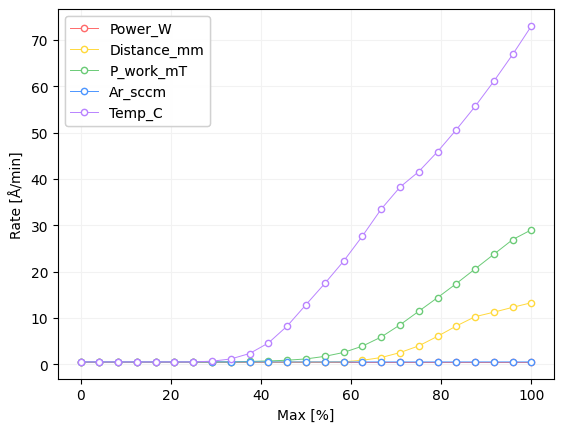

In [ ]:
import itertools

#colors = ['#69B3CF', '#A9C9D8', '#1296D4', '#2E2E2E', '#F2F2F2']
colors = ['#FF6B6B',  # soft coral
 '#FFD93D',  # warm sunshine yellow
 '#6BCB77',  # fresh mint green
 '#4D96FF',  # happy sky blue
 '#B983FF']  # soft lavender

cc = itertools.cycle(colors)
plot_lines = []

# Space for optimitation
#x00_range = [1,1]       # TiN
#x01_range = [1,1]       # RF
#  x02_range = [0,60]       # Power_W
#  x03_range = [44.5,146]   # Distance_mm
#  x04_range = [3,60]       # P_work_mT
#  x05_range = [1,20]       # Ar_sccm
#x06_range = [0,20]      # N2_sccm
#x07_range = [0,100]     # Ar_per
#x08_range = [0,100]     # N2_per
#  x09_range = [25,450]     # Temp_C
#x10_range = [0,0.4]     # Bias_kV
#x11_range = [2,2]       # TargetDiameter_in

minimum = [1, 1, x02_range[0], x03_range[0], x04_range[0], x05_range[0], 0, 100, 0, x09_range[0], 0, 2]

steps = 25
for i in range(12):

  match i:

    case 2: # Power_W
      var_range = x02_range

    case 3: # Distance_mm
      var_range = x03_range

    case 4: # P_work_mT
      var_range = x04_range

    case 5: # Ar_sccm
      var_range = x05_range

    case 9: # Temp_C
      var_range = x09_range

    case _:
      continue

  var_x = minimum.copy()
  var_xs = np.linspace(var_range[0], var_range[1], steps)
  plot_y = np.zeros(steps, dtype=float)

  for step in range(steps):
    var_x[i] = var_xs[step]
    var_y = myFunc(var_x)
    plot_y[step] = var_y.item()

  # Normalize to %
  diff = var_xs.max() - var_xs.min()
  plot_x = (var_xs-var_xs.min()) / diff * 100;
  plot_y = plot_y + abs(plot_y.min())

  l1, = plt.plot(plot_x, plot_y,
    linestyle='-',
    marker='o',
    linewidth=0.7,          # thinner line
    markersize=4.5,         # ball size
    markerfacecolor='white',# hollow circle
    markeredgewidth=1.0,
    color=next(cc))
  plot_lines.append(l1)

#end

legend1 = plt.legend(plot_lines, ["Power_W", "Distance_mm" , "P_work_mT", "Ar_sccm", "Temp_C"], loc='upper left')
plt.gca().add_artist(legend1)

plt.grid(color='0.95')
#plt.show()

plt.xlabel("Max [%]")
plt.ylabel("Rate [Å/min]")
#plt.ylim(0, 60)
